# PySAM for a Single Location

Run a PySAM `pvsamv1` simulation for a single location, inspect the model output
dictionary, and visualize the spatial rear-side **ground irradiance** profile
beneath a bifacial array.

This notebook uses a cached NSRDB weather file for New York City that ships with
the repository, so it runs fully offline with no API key or network access
required.

In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pvdeg
from pvdeg import DATA_DIR

In [2]:
# Load cached NSRDB weather for New York City, shipped with the pvdeg package.
# Reproducible and fully offline (no API key or network), and resolves from a pip
# install as well as a repo clone.
weather_path = os.path.join(DATA_DIR, "psm4_nyc.csv")
meta_path = os.path.join(DATA_DIR, "meta_nyc.json")

weather = pd.read_csv(weather_path, index_col=0, parse_dates=True)
with open(meta_path, "r") as f:
    meta = json.load(f)

meta

{'Source': 'NSRDB',
 'Location ID': '1245247',
 'City': '-',
 'State': '-',
 'Country': '-',
 'Clearsky DHI Units': 'w/m2',
 'Clearsky DNI Units': 'w/m2',
 'Clearsky GHI Units': 'w/m2',
 'Dew Point Units': 'c',
 'DHI Units': 'w/m2',
 'DNI Units': 'w/m2',
 'GHI Units': 'w/m2',
 'Solar Zenith Angle Units': 'Degree',
 'Temperature Units': 'c',
 'Pressure Units': 'mbar',
 'Relative Humidity Units': '%',
 'Precipitable Water Units': 'cm',
 'Wind Direction Units': 'Degrees',
 'Wind Speed Units': 'm/s',
 'Cloud Type -15': 'N/A',
 'Cloud Type 0': 'Clear',
 'Cloud Type 1': 'Probably Clear',
 'Cloud Type 2': 'Fog',
 'Cloud Type 3': 'Water',
 'Cloud Type 4': 'Super-Cooled Water',
 'Cloud Type 5': 'Mixed',
 'Cloud Type 6': 'Opaque Ice',
 'Cloud Type 7': 'Cirrus',
 'Cloud Type 8': 'Overlapping',
 'Cloud Type 9': 'Overshooting',
 'Cloud Type 10': 'Unknown',
 'Cloud Type 11': 'Dust',
 'Cloud Type 12': 'Smoke',
 'Fill Flag 0': 'N/A',
 'Fill Flag 1': 'Missing Image',
 'Fill Flag 2': 'Low Irradiance',
 

In [3]:
out_dict = pvdeg.pysam.pysam(
    weather_df=weather,
    meta=meta,
    pv_model="pvsamv1",
    pv_model_default="FlatPlatePVCommercial",
)
for key in sorted(out_dict.keys()):
    print(key)

ac_gross
ac_lifetime_loss
ac_perf_adj_loss
ac_transmission_loss
ac_wiring_loss
airmass
alb
annual_ac_gross
annual_ac_inv_clip_loss_percent
annual_ac_inv_eff_loss_percent
annual_ac_inv_pnt_loss_percent
annual_ac_inv_pso_loss_percent
annual_ac_lifetime_loss_percent
annual_ac_loss_ond
annual_ac_perf_adj_loss_percent
annual_ac_wiring_loss
annual_ac_wiring_loss_percent
annual_bifacial_electrical_mismatch
annual_bifacial_electrical_mismatch_percent
annual_dc_diodes_loss
annual_dc_diodes_loss_percent
annual_dc_gross
annual_dc_inv_tdc_loss_percent
annual_dc_invmppt_loss
annual_dc_lifetime_loss_percent
annual_dc_loss_ond
annual_dc_mismatch_loss
annual_dc_mismatch_loss_percent
annual_dc_module_loss_percent
annual_dc_mppt_clip_loss_percent
annual_dc_nameplate_loss
annual_dc_nameplate_loss_percent
annual_dc_net
annual_dc_nominal
annual_dc_optimizer_loss
annual_dc_optimizer_loss_percent
annual_dc_perf_adj_loss_percent
annual_dc_snow_loss_percent
annual_dc_tracking_loss
annual_dc_tracking_loss_perce

In [4]:
# Most outputs are scalars or 1-D time series. A few are 2-D matrices, returned
# as a tuple whose entries are themselves tuples (rows). Find those.
for key, item in out_dict.items():
    if isinstance(item, tuple) and item and isinstance(item[0], tuple):
        print(key)

annual_energy_distribution_time
subarray1_ground_rear_spatial
subarray1_poa_rear_spatial


## Spatial ground irradiance

A few outputs describe irradiance that varies *across* the ground between module
rows and are returned as 2-D matrices (a tuple of row tuples):

- `subarray1_ground_rear_spatial` &mdash; rear-side irradiance reaching the ground.
- `subarray1_poa_rear_spatial` &mdash; rear-side plane-of-array irradiance.

We visualize `subarray1_ground_rear_spatial`, which matters for agrivoltaics: it
tells us how much light reaches the ground beneath a bifacial array. Its layout is:

- **Row `0`** &mdash; the ground positions (in metres) where irradiance is
  evaluated. The leading value is a `0` placeholder.
- **Rows `1:`** &mdash; one row per hourly timestep. The leading value is the
  timestep index; the remaining values are the irradiance at each position.

In [5]:
spatial = out_dict["subarray1_ground_rear_spatial"]

# Row 0 holds the ground positions (drop the leading placeholder).
# In every data row, column 0 is the timestep index, so drop it too.
distances = np.array(spatial[0])[1:]
ground_irradiance = np.array(spatial[1:])[:, 1:]  # shape: (hours, positions)

# Pick the sunniest day (greatest total rear ground irradiance) to visualize.
daily_total = ground_irradiance.reshape(-1, 24, distances.size).sum(axis=(1, 2))
best_day = int(daily_total.argmax())

day_slice = slice(best_day * 24, best_day * 24 + 24)
day_index = weather.index[day_slice]
day_irradiance = ground_irradiance[day_slice]

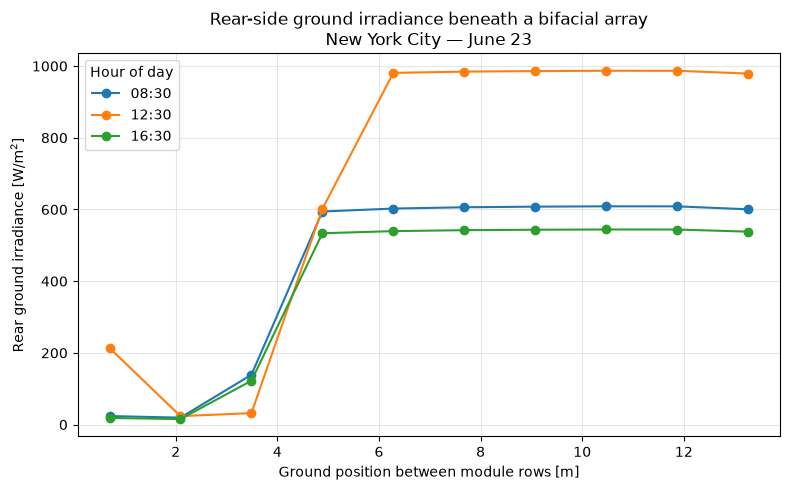

In [6]:
# Ground irradiance varies across the pitch because the module rows cast a moving
# shadow. Plot the spatial profile at a few hours to see the shading band shift.
fig, ax = plt.subplots(figsize=(8, 5))

for hour in (8, 12, 16):
    ax.plot(
        distances,
        day_irradiance[hour],
        marker="o",
        label=day_index[hour].strftime("%H:%M"),
    )

ax.set_xlabel("Ground position between module rows [m]")
ax.set_ylabel("Rear ground irradiance [W/m$^2$]")
ax.set_title(
    "Rear-side ground irradiance beneath a bifacial array\n"
    f"New York City \u2014 {day_index[0].strftime('%B')} {day_index[0].day}"
)
ax.legend(title="Hour of day")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()